## Summary
**Goal:** Assign delivery orders to drivers and sequence routes to **minimize average delivery duration**
> while ensuring **feasible routes**, **reasonable driver utilization**, and **practical runtime**.

## **Problem Statement**
Design a routing and assignment strategy that efficiently matches delivery orders to drivers under time and distance constraints, balancing **solution quality** and **computational speed**.
Write a solver that assigns deliveries to drivers to maximize the average deliveries/hour across drivers, with a target level of service of average delivery duration being < 45 minutes, solving less than a minute.

## **Methodology Overview**
- **Data validation & EDA** to understand distance, timing, and feasibility patterns
- **Greedy baseline** for fast, feasible route construction
- **Optimization-based approach (MIP / Column-Generation)** to improve routing quality, this is provided in the Appendix.
- **Evaluation metrics**:
  - **Average delivery duration (minutes)**
  - **Deliveries per driver per hour**
  - **Feasibility & solve time**

## **Key Results**
- Solved both questions under the constraints via greedy approach. Although MIP with column generation also performs well.
- Bonus question was solved with first a feasibility check, and then fleet-search and fleet compression.

## **Recommendation**
> **Use greedy routing for fast initial feasibility and as a fallback.**
> **Apply optimization when runtime allows or when SLAs are tight.**

### **End-to-End Pipeline**
**Data → Validation → Greedy Baseline → Optimization → Metrics & Comparison**

## Notebook Contents
- [1. Setup & Inputs](#1-setup--inputs)
- [2. Data Prep & EDA](#2-data-prep--eda)
- [3. Optimization Formulation](#3-optimization-model-formulation)
- [4. Greedy / Baseline Solver](#4-greedy--baseline-solver)
- [5. Bonus: <50 Drivers Feasibility](#5-bonus-50-Drivers-feasibility)
- [6. Results Dashboard (from CSV outputs)](#6-results-dashboard-from-csv-outputs)
- [7. Appendix: Column Generation and MIP](#7-route-assignment-via-column-generation)


<a id="1-setup--inputs"></a>
# 1) Setup & Inputs


In [1]:
%%capture
import sys
!{sys.executable} -m pip install seaborn
!pip install matplotlib
!pip install scipy
!pip install dataprep
!pip install pyDOE
!pip install pyomo
!conda install -y -c conda-forge glpk
#print(_.stdout)

In [2]:
# Standard library
import sys
import time
import math
import logging
from contextlib import contextmanager
from typing import Any, Dict, Tuple, List, Union

# Third-party libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Optimization/modeling
import pyomo.environ as pyo
from pyomo.opt import SolverFactory, SolverStatus, TerminationCondition

# Modules
from modules import data_prep, utilities, mip_solver, greedy, bonus, visualizations

22:52:04 | INFO | Logging configured (level=INFO).


In [1]:
# -------------------------
# User configurations
# -------------------------
SPEED_M_PER_SEC = 4.5
INPUT_PATH = 'data/input.csv'
GREEDY_OUTPUT_PATH = 'output.csv'
BONUS_OUTPUT_PATH = 'bonus_output.csv'
RUN_GREEDY = True
RUN_BONUS = True
RUN_COLUMN_GENERATION = False
RUN_MIP = False

In [4]:
deliveries_df = pd.read_csv(INPUT_PATH)

<a id="2-data-prep--eda"></a>
# 2) Data Prep & EDA


In [5]:
deliveries_df = data_prep.add_distance_and_time_columns(deliveries_df,speed_m_per_sec=SPEED_M_PER_SEC)
deliveries_df

,delivery_id,created_at,food_ready_time,region_id,pickup_lat,pickup_long,dropoff_lat,dropoff_long,haversine_km,delivery_time_sec,delivery_time_min
0,1,2/3/15 2:00,2/3/15 2:13,82,37.478223,-122.186786,37.457380,-122.153508,3.741227,831.383762,13.856396
1,2,2/3/15 2:00,2/3/15 2:10,70,37.401156,-122.112309,37.419256,-122.149557,3.856663,857.036282,14.283938
2,3,2/3/15 2:01,2/3/15 2:27,82,37.446389,-122.161019,37.452685,-122.138039,2.145982,476.884877,7.948081
3,4,2/3/15 2:01,2/3/15 2:29,82,37.445577,-122.161317,37.422185,-122.203131,4.516258,1003.612809,16.726880
4,5,2/3/15 2:02,2/3/15 2:25,82,37.452254,-122.182500,37.418843,-122.209201,4.400017,977.781641,16.296361
...,...,...,...,...,...,...,...,...,...,...,...
202,203,2/3/15 2:59,2/3/15 3:31,82,37.444318,-122.163014,37.447627,-122.140746,1.999954,444.434299,7.407238
203,204,2/3/15 2:59,2/3/15 3:26,82,37.413739,-122.125722,37.448382,-122.154511,4.615225,1025.605553,17.093426
204,205,2/3/15 2:59,2/3/15 3:23,9,37.565000,-122.321600,37.583602,-122.342913,2.794053,620.900757,10.348346
205,206,2/3/15 2:59,2/3/15 3:23,70,37.394592,-122.078631,37.398238,-122.052329,2.358603,524.133895,8.735565


Shape: (207, 12)

Dtypes:
 delivery_id                   int64
created_at           datetime64[ns]
food_ready_time      datetime64[ns]
region_id                     int64
pickup_lat                  float64
pickup_long                 float64
dropoff_lat                 float64
dropoff_long                float64
haversine_km                float64
delivery_time_sec           float64
delivery_time_min           float64
ready_gap_min               float64
dtype: object

Missingness (top):
 Empty DataFrame
Columns: [missing_count, missing_pct]
Index: []

Key metric stats:
                    count       mean       std       min        1%         5%  \
haversine_km       207.0   2.960183  1.462592  0.266569  0.402000   0.574456   
delivery_time_min  207.0  10.963641  5.417007  0.987292  1.488887   2.127615   
ready_gap_min      207.0  27.164251  8.591149  6.000000  8.060000  13.000000   

                         50%        95%        99%        max  
haversine_km        2.794053   5.3293

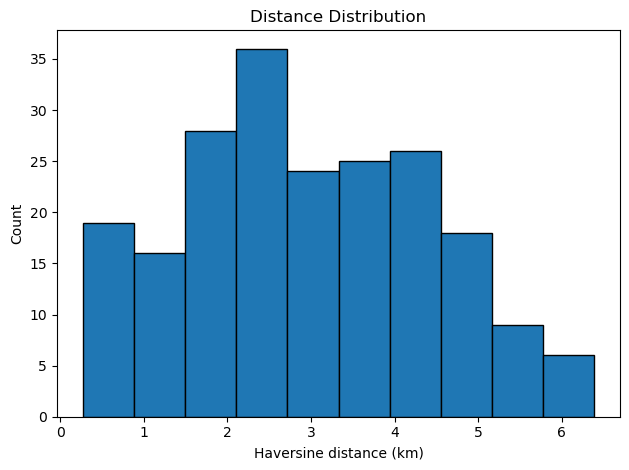

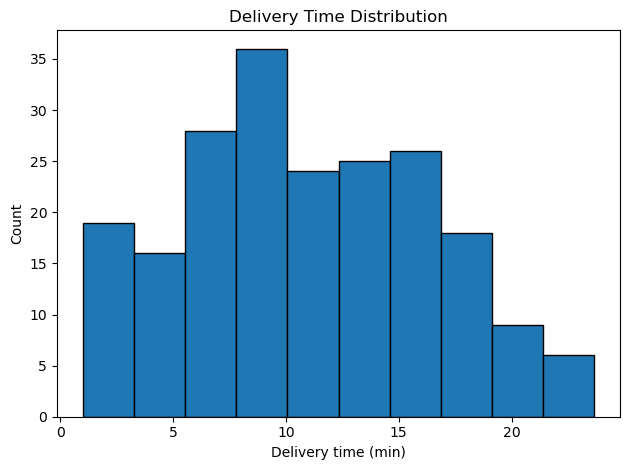


No suspicious rows flagged by simple rules.


(     delivery_id          created_at     food_ready_time  region_id  \
 0              1 2015-02-03 02:00:00 2015-02-03 02:13:00         82   
 1              2 2015-02-03 02:00:00 2015-02-03 02:10:00         70   
 2              3 2015-02-03 02:01:00 2015-02-03 02:27:00         82   
 3              4 2015-02-03 02:01:00 2015-02-03 02:29:00         82   
 4              5 2015-02-03 02:02:00 2015-02-03 02:25:00         82   
 ..           ...                 ...                 ...        ...   
 202          203 2015-02-03 02:59:00 2015-02-03 03:31:00         82   
 203          204 2015-02-03 02:59:00 2015-02-03 03:26:00         82   
 204          205 2015-02-03 02:59:00 2015-02-03 03:23:00          9   
 205          206 2015-02-03 02:59:00 2015-02-03 03:23:00         70   
 206          207 2015-02-03 02:59:00 2015-02-03 03:29:00         70   
 
      pickup_lat  pickup_long  dropoff_lat  dropoff_long  haversine_km  \
 0     37.478223  -122.186786    37.457380   -122.153508    

In [6]:
data_prep.run_initial_eda(deliveries_df = deliveries_df, speed_m_per_sec = SPEED_M_PER_SEC, show_plots = True, verbose = True)

<a id="3-optimization-model-formulation"></a>
# 3) Optimization Model Formulation

This section defines a **Mixed-Integer Program (MIP)** for assigning deliveries to drivers and scheduling their service times.
  
### Sets and Indices

- $D$: set of deliveries, indexed by $i,k$
- $J$: set of drivers, indexed by $j$
- Add a dummy start node $0$ (one per driver) to represent “start of route”.

### Parameters

**Units:** use **seconds** for time everywhere.

#### Time stamps
- $c_i$: created time of delivery $i$ (UTC, in seconds)
- $r_i$: food ready time of delivery $i$ (UTC, in seconds)
- $T_0$: global route start time (UTC), e.g. **2015-02-03 02:00:00 UTC**
(All times should be in the same unit (here we use seconds))

#### Travel-time model
Let $v = 4.5$ m/s be speed and let $\text{dist}(\cdot,\cdot)$ be haversine distance in meters.

- $\tau_i$: travel time from pickup to dropoff for delivery $i$

$$
\tau_i \;=\; \frac{\text{dist}(p_i, d_i)}{v}
$$

- $\tau_{ik}$: travel time from dropoff of $i$ to pickup of $k$

$$
\tau_{ik} \;=\; \frac{\text{dist}(d_i, p_k)}{v}
$$

#### Service level target
- $L$: average delivery duration target in seconds  
  (e.g. $L = 45 \times 60$)

#### Big-M constant
- $M$: sufficiently large time constant (e.g. $M = 24 \times 3600$)
- Note that we can tighten this to improve the performance of the MIP.

### Decision Variables

#### Assignment variables
- $x_{ij} \in \{0,1\}$:

$$
x_{ij} =
\begin{cases}
1 & \text{if delivery } i \text{ is assigned to driver } j \\
0 & \text{otherwise}
\end{cases}
$$

#### Sequencing variables
- $y_{ikj} \in \{0,1\}$: delivery $k$ is immediately after $i$ on driver $j$
- $y_{0ij} \in \{0,1\}$: delivery $i$ is first on driver $j$

#### Timing variables
- $s_{ij} \ge 0$: pickup time of delivery $i$ if served by driver $j$
- $t_j \ge 0$: route end time for driver $j$

#### Metric variables
- $u_i \ge 0$: delivery duration for delivery $i$


### Constraints

**- Each delivery assigned to exactly one driver**

$$
\sum_{j \in J} x_{ij} = 1
\quad \forall i \in D
$$

**- Food-ready feasibility**

$$
s_{ij} \;\ge\; r_i \;-\; M(1-x_{ij})
\quad \forall i \in D,\; \forall j \in J
$$


**- Route start time**

$$
s_{ij} \;\ge\; T_0 \;-\; M(1-x_{ij})
\quad \forall i \in D,\; \forall j \in J
$$

#### Route sequencing constraints

**- One predecessor if assigned**

$$
y_{0ij} + \sum_{k \in D,\; k \ne i} y_{kij} = x_{ij}
\quad \forall i \in D,\; \forall j \in J
$$


**- At most one successor**

$$
\sum_{k \in D,\; k \ne i} y_{ikj} \le x_{ij}
\quad \forall i \in D,\; \forall j \in J
$$

**- At most one first delivery per driver**

$$
\sum_{i \in D} y_{0ij} \le 1
\quad \forall j \in J
$$

**- Time propagation along route**

$$
s_{kj} \;\ge\; s_{ij} + \tau_i + \tau_{ik} \;-\; M(1-y_{ikj})
\quad \forall i \ne k \in D,\; \forall j \in J
$$

#### Route end time

$$
t_j \;\ge\; s_{ij} + \tau_i \;-\; M(1-x_{ij})
\quad \forall i \in D,\; \forall j \in J
$$

Route duration (derived):

$$
T_j^{\text{route}} = t_j - T_0
$$

### Delivery duration and service level

$$
u_i \;\ge\; (s_{ij} + \tau_i - c_i) \;-\; M(1-x_{ij})
\quad \forall i \in D,\; \forall j \in J
$$

Average delivery duration constraint:

$$
\frac{1}{|D|} \sum_{i \in D} u_i \;\le\; L
$$


### Objective Function
The metric that we'd like to maximize is:

$$
\text{Deliveries/hour}
\;=\;
\frac{|D|}{\sum_{j \in J}(t_j - T_0)} \times 3600
$$

which translates into the following after removing constant terms:
$$
\min \sum_{j \in J}(t_j - T_0)
$$


<div style="
    width: 70%;
    margin: 30px auto;
    border-top: 5px solid #1f77b4;
"></div>



## Methodology

### Problem Classification

The problem at hand can be classified as a **Pickup-and-Delivery Vehicle Routing Problem with Time Windows (PDVRPTW)** with a **system-level throughput objective**.  
This problem is commonly referred to as **order batching and courier assignment**.


### Computational Complexity

This problem is **NP-hard**, even under deterministic assumptions and with full knowledge of future demand.

More specifically:

- The **Vehicle Routing Problem (VRP)** is NP-hard.
- The **Pickup-and-Delivery Problem (PDP)** is NP-hard.
- Introducing **time windows and release times** (e.g., food readiness constraints) makes the problem **strongly NP-hard**.
- Incorporating **routing-dependent objectives** (such as deliveries per hour or average delivery duration) further increases computational complexity.

Even highly simplified versions of this problem, such as a single vehicle with no time windows, reduce to the **Traveling Salesman Problem (TSP)**, which is itself NP-hard. 


### Solution Approaches in Theory and Practice

#### Academic Perspective

The approach would be to formulate the problem as an exact **Mixed-Integer Program (MIP)** and address scalability via **decomposition techniques**, such as:

- **Dantzig–Wolfe decomposition**
- **Column generation / branch-and-price**

#### Industry Practice

In industry settings, **runtime, robustness, and operational simplicity** are typically prioritized over strict optimality. So, practical solutions often rely on faster approximation methods, including:

- **Greedy construction heuristics**
- **Local search and improvement heuristics**
- **Divide-and-conquer or hierarchical optimization strategies**

We can also decompose the global routing problem into multiple stages, such as:

1. **Clustering / zoning** — group orders spatially and temporally
2. **Batching** — decide which orders can be bundled together
3. **Routing** — determine the sequence of pickups and dropoffs within each batch
4. **Assignment** — assign batches or routes to drivers

This staged approach can significantly reduce computational complexity while still producing high-quality, feasible solutions within strict runtime limits.

## Comparison of Solution Approaches: Academia vs. Industry

| Perspective | Approach | Key Idea | Pros | Cons |
|------------|----------|----------|------|------|
| Academia | Exact MIP | Full PDVRPTW formulation | <span style="color: green;">✅ Optimal</span><br><span style="color: green;">✅ Clean theory</span> | <span style="color: red;">❌ Poor scalability</span><br><span style="color: red;">❌ Too slow</span> |
| Academia | Branch-and-Price | Route-based decomposition | <span style="color: green;">✅ Near-optimal</span><br><span style="color: green;">✅ Better scaling</span> | <span style="color: red;">❌ Complex</span><br><span style="color: red;">❌ Hard pricing</span> |
| Academia | Column Generation | LP with dynamic routes | <span style="color: green;">✅ Strong bounds</span> | <span style="color: red;">❌ Rounding needed</span><br><span style="color: red;">❌ Still heavy</span> |
| Industry | Greedy Heuristic | Incremental construction | <span style="color: green;">✅ Very fast</span><br><span style="color: green;">✅ Simple</span> | <span style="color: red;">❌ Suboptimal</span> |
| Industry | Local Search | Improve initial solution | <span style="color: green;">✅ Big gains</span><br><span style="color: green;">✅ Fast</span> | <span style="color: red;">❌ Local minima</span> |
| Industry | Staged Optimization | Cluster → batch → route | <span style="color: green;">✅ Scales well</span><br><span style="color: green;">✅ Modular</span> | <span style="color: red;">❌ Decomposition loss</span> |


### Approach for This Assignment

For the initial solution, I begin with a **greedy heuristic** to construct feasible routes and assignments efficiently. This provides a fast and interpretable baseline that satisfies the runtime constraints of the problem.

<div style="
    width: 70%;
    margin: 30px auto;
    border-top: 5px solid #1f77b4;
"></div>


<a id="4-greedy--baseline-solver"></a>
# 4) Greedy / Baseline Solver

I use a **constructive heuristic** that builds routes quickly while controlling the service-level metric.

### Core idea

Each driver maintains a current state:
- current time $t_j$
- current location (initially at the first pickup; we do not model starting locations)
- a route (sequence of deliveries)

At each step, we choose the **best next (driver, delivery)** pair using an incremental score.


### Travel / timing model

Let $r_i$ be food-ready time and $c_i$ be created time (all in seconds).

If driver $j$ is at time $t_j$ and location $\ell_j$ and we consider assigning delivery $i$ next:

- travel-to-pickup time: $\tau(\ell_j \rightarrow p_i)$
- pickup time:
$$
s = \max(t_j + \tau(\ell_j \rightarrow p_i),\ r_i)
$$
- dropoff time:
$$
d = s + \tau_i
$$
where $\tau_i$ is pickup→dropoff travel time for delivery $i$.
- delivery duration:
$$
u_i = d - c_i
$$
- incremental route time:
$$
\Delta = d - t_j
$$


### Greedy selection rule (with SLA penalty)

We score candidate delivery $i$ for driver $j$ as:

$$
\text{score}(i,j) = \Delta + \alpha \cdot \max(0,\ u_i - L)
$$

- $\Delta$ pushes the heuristic to reduce total route time (improves deliveries/hour)
- the penalty term discourages assignments that inflate delivery duration beyond the target $L = 45\text{ minutes}$

At each iteration, we pick the (driver, delivery) with **minimum score**, assign it, and update that driver’s state.

To keep runtime low, we restrict candidates (e.g., same region + time window + optional top-$K$ nearest).


## Choosing number of drivers

Because average duration is a *global* constraint, we run the heuristic with an initial number of drivers and increase drivers until:

$$
\frac{1}{|D|}\sum_{i \in D} u_i \le L
$$

This also naturally targets the bonus “< 50 drivers” if feasible.

In [7]:
if RUN_GREEDY:
    # -------------------------
    # Run + time in minutes
    # -------------------------
    t0 = time.perf_counter()
    
    assignment_df, metrics = greedy.solve_with_min_drivers(
        deliveries_df=deliveries_df,
        T0_utc="2015-02-03 02:00:00",
        start_drivers=10,
        max_drivers=60,
        drivers_step=5,
        alpha=2.0,
        time_window_s=3600,
        use_region=True,
        top_k=50,
        verbose=False,
    )
    
    t1 = time.perf_counter()
    runtime_min = (t1 - t0) / 60.0
    print(f"Runtime: {runtime_min:.3f} minutes")
    
    # ---------------------------------------------------------
    # Build CSV output
    # ---------------------------------------------------------
    
    submission_df, metrics = utilities.create_outputs(assignment_df=assignment_df, output_csv_path=GREEDY_OUTPUT_PATH, print_metrics=True)
    
    print(submission_df.head(10))

Runtime: 0.462 minutes

=== Requested Output Metrics ===
Average deliveries/hour across all dashers: 2.323
Average delivery duration across all deliveries (min): 44.398

Wrote submission CSV: output.csv
  Route ID  Route Point Index  Delivery ID Route Point Type  Route Point Time
0        0                  0           22           Pickup        1422929460
1        0                  1           22          DropOff        1422929829
2        0                  2           37           Pickup        1422930360
3        0                  3           37          DropOff        1422930696
4        0                  4           55           Pickup        1422931161
5        0                  5           55          DropOff        1422931324
6        0                  6           38           Pickup        1422931447
7        0                  7           38          DropOff        1422931707
8        0                  8          107           Pickup        1422931951
9        0       

In [8]:
# ---------------------------------------------------------
# Evaluate using the provided solution_evaluator
#
# Notes:
# 1) A minimal fix is required in the evaluator:
#    replace the incorrect label "dropOff" with "dropoff".
# 2) The evaluator triggers a Pandas FutureWarning related to
#    DataFrameGroupBy.apply(). Since this is external code and
#    its logic is unchanged, the warning is silenced here to
#    improve notebook readability.
# ---------------------------------------------------------

import warnings
warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    message="DataFrameGroupBy.apply"
)

import solution_evaluator

the efficiency is 2.3230005735803885


<div style="background-color:#e8f5e9; border-left:6px solid #2e7d32; padding:14px; font-size:15px;">
  <div style="font-size:18px; font-weight:600; margin-bottom:6px;">
    ✅ Conclusion
  </div>
  The proposed greedy solution with penalty performs well and meets all assignment requirements.<br>
  It runs in under one minute (≈46 seconds) and achieves an average delivery duration of
  <strong>less than 45 minutes</strong> across all deliveries and Average deliveries/hour across all drivers >= 2 🎉
</div>


<a id="5-bonus-50-driverss-feasibility"></a>
# 5) Bonus: <50 Drivers Feasibility


This extension is a **fleet-minimizing PDVRPTW**, a well-known and challenging NP-hard variant of the problem.

## Bonus Feasibility Check (≤ 50 drivers, avg duration < 45 min, runtime < 1 min)

Before investing in heavier optimization for the bonus constraint, I treated the task as a **feasibility diagnosis** problem.

**Step 1 — Fast infeasibility screen (lower bound):**  
For each delivery \(i\), compute an optimistic lower bound on delivery duration:
$$
LB_i = \max(0, r_i - c_i) + t^{pickup\to dropoff}_i
$$
This assumes the driver is immediately available at pickup at time $r_i$. Since any real route can only add waiting/travel, $LB_i$ is a valid lower bound.  
If $\frac{1}{n}\sum_i LB_i \ge 45$ minutes, the bonus target is infeasible under the problem’s assumptions.

**Step 2 — Constructive feasibility-first heuristic:**  
If the lower bound does not rule out feasibility, I run a feasibility-oriented greedy scheduler (not throughput-oriented) that prioritizes orders with low slack and minimizes incremental delivery duration. If this produces a solution using ≤ 50 drivers with avg duration < 45 minutes, it serves as a constructive witness of feasibility.

**Step 3 — Fleet-size search:**  
To estimate the minimum fleet size required, I treat the heuristic as a decision test and run it across different $K$, using a binary search to identify the smallest $K$ that yields a feasible schedule.

**Step 4 — Fleet compression:**  Since feasibility was achieved at K=52 (avg duration 44.48) at step 3, I applied a fleet-compression post-processing step: iteratively eliminate the least-loaded drivers and greedily reinsert their deliveries into remaining routes while preserving avg duration ≤ 45. 

In [9]:
if RUN_BONUS:
    t0 = time.perf_counter()
    # Run the full bonus feasibility + min-fleet compression
    assignment_df, metrics = bonus.run_bonus_feasibility_and_min_fleet(
        deliveries_df,
        T0_utc="2015-02-03 02:00:00",
        target_avg_min=45.0,
        target_K=50,
        K_low=10,
        K_high=200,
        coarse_step=5,
        refine_window=10,
        variants_per_K=5,
        speed_m_per_sec=4.5,
        verbose=True,
    )
    
    t1 = time.perf_counter()
    runtime_min = (t1 - t0) / 60.0
    print(f"Runtime for all four steps (feasibility check and compressing fleet): {runtime_min:.3f} minutes")
    
    # ----------------
    # Build CSV output
    # ----------------
    
    submission_df, metrics = utilities.create_outputs(assignment_df=assignment_df, output_csv_path=BONUS_OUTPUT_PATH, print_metrics=True)
    
    print(submission_df.head(10))

[TIMER] Step 1 - Lower-bound feasibility screen ...
LB mean duration: 38.13 min
[TIMER]   - computed LB mean: 0.027s (since last), 0.027s (total)
[TIMER] Step 1 - Lower-bound feasibility screen done in 0.027s
[TIMER] Step 2+3 - Min-K search via greedy variants ...
[TIMER]   - completed K-search: 9.393s (since last), 9.421s (total)
[TIMER] Step 2+3 - Min-K search via greedy variants done in 9.393s
found
min_K: 52
avg_duration_min: 44.47594525867806
avg_deliveries_per_hour: 2.3759573016368982
[TIMER] Step 4 - Fleet compression toward target_K ...
compression: {'status': 'done', 'avg_duration_min': 44.99648395337153, 'used_dashers': 50, 'eliminated_dashers': [7, 8]}
[TIMER]   - compression finished: 58.988s (since last), 68.409s (total)
[TIMER] Step 4 - Fleet compression toward target_K done in 58.988s
[TIMER] Final - Compute metrics ...
[TIMER]   - metrics computed: 0.002s (since last), 68.411s (total)
[TIMER] Final - Compute metrics done in 0.002s
Runtime for all four steps (feasibility

<div style="background-color:#e8f5e9; border-left:6px solid #2e7d32; padding:14px; font-size:15px;">
  <div style="font-size:18px; font-weight:600; margin-bottom:6px;">
    ✅ Bonus Achieved (Fleet ≤ 50)
  </div>
  • Lower-bound feasibility check: mean LB = <strong>38.13 min</strong><br>
  • Greedy feasibility baseline: <strong>K = 52</strong>, avg duration = <strong>44.48 min</strong><br>
  • Fleet compression post-processing: <strong>K = 50</strong>, avg duration = <strong>44.996 min</strong> ✅<br>
  • Avg deliveries/hour > <strong>2</strong> ✅<br>
  • Note that Step 4, fleet compression toward target_K is done in < 1 min. ✅<br>
</div>


<div style="
    width: 70%;
    margin: 30px auto;
    border-top: 5px solid #1f77b4;
"></div>

<a id="6-results-dashboard-from-csv-outputs"></a>
# 6) Results Dashboard (from CSV outputs)

> If you re-run the solvers and overwrite the CSVs, this dashboard will automatically reflect the latest results.


In [10]:
results = visualizations.run_solution_dashboard()

,Solution,Routes (#),Deliveries (#),Avg duration (min),P90 duration (min),Avg deliveries/route,Total route span (hr)
0,main,55,207,NaN,NaN,NaN,57.44
1,bonus,50,207,NaN,NaN,NaN,59.82


<a id="7-route-assignment-via-column-generation"></a>
# 7) Appendix (Route Assignment via Column Generation + MIP solver)

The appendix includes the MIP code as well as the column generation code I did for my own interest here.
# Route Assignment via Column Generation

### Problem Overview

This problem naturally leads to a **set partitioning formulation**, where each feasible route is a column.  
However, the number of possible routes grows exponentially, making full enumeration infeasible.

To handle this, we use **Column Generation (CG)**.


### High-Level Approach

The algorithm consists of three main stages:

1. **Initial Route Pool Construction**  
2. **Restricted Column Generation Loop (LP relaxation + pricing)**  
3. **Final Integer Master Solve**

### 1. Initial Route Pool Construction

We start by building a **small but diverse** set of feasible routes.

#### Included route types

- **Singleton routes**  
  One delivery per route. These guarantee coverage feasibility.

- **Short routes (pairs)**  
  Built using *k*-nearest neighbors (KNN) based on pickup locations.

- **Greedy extended routes**  
  Routes are extended from random seeds by repeatedly selecting the next delivery that minimally increases route cost.

#### Design choices

- Pickup-based KNN keeps candidate routes geographically compact.
- Greedy extension avoids full combinatorial enumeration.
- Route length is capped to keep simulation costs low.

The initial pool is pruned to a fixed size using a dominance rule based on:
- route length,
- route cost,
- total delivery duration.

### 2. Feasibility Injection

To ensure the master problem is always feasible under the driver limit, we inject a **guaranteed-feasible cover**.

- Deliveries are sorted by ready time.
- Routes are grown greedily until all deliveries are assigned.
- The total number of routes is explicitly capped by the driver limit.

These routes are added only if they are not already present in the pool.

This step ensures:
- feasibility of the master problem,
- robustness when SLA or driver limits are tight.

### 3. Restricted Column Generation Loop

We now iteratively improve the route pool.

#### 3.1 LP Relaxed Master Problem

We solve the **LP relaxation** of the master problem.

**Decision variable**

$$
z_r \in [0,1] \quad \text{for each route } r
$$

**Objective**

$$
\min \sum_r c_r z_r
$$

**Constraints**

- **Coverage**: each delivery is covered exactly once  
- **Route count**: number of selected routes does not exceed the driver limit  
- **SLA**: average delivery duration does not exceed the threshold  

From the LP solution, we extract **dual variables**:
- coverage duals for each delivery,
- SLA dual,
- route-count dual.

#### 3.2 Pricing Heuristic (Column Generation)

Using the duals, we search for new routes with **negative reduced cost**.

The reduced cost of a route is:

$$
\text{Reduced Cost} =
\text{route cost}
- \sum_{i \in \text{route}} \pi_i
- \lambda \cdot (\text{route duration})
$$

##### Pricing strategy

- Seed routes from deliveries with high coverage dual values.
- Extend routes greedily using KNN neighborhoods.
- Explore only a small number of candidate extensions.
- Stop extending when reduced cost stops improving.

This heuristic avoids solving an expensive shortest-path pricing subproblem while still generating high-quality columns.

Only routes with **strictly negative reduced cost** are added to the pool.


#### 3.3 Pool Management

After each pricing iteration:

- new columns are added,
- the pool is pruned to a fixed maximum size,
- pruning favors short, low-cost, and low-duration routes.

The column generation loop runs for a small, fixed number of iterations or until no improving columns are found.

### 4. Final Integer Master Solve

Once column generation terminates, we solve the **integer master problem**:

$$
z_r \in \{0,1\}
$$

using the same objective and constraints as the LP relaxation.


### Performance Considerations

Key optimizations used in the implementation:

- Cached timestamps and coordinates to avoid repeated conversions.
- KNN construction via partial sorting (`argpartition`).
- Aggressive reuse of route simulation results inside heuristics.
- Explicit caps on pricing iterations and branching factors.
- Explicit control of column pool size.

Empirically, the full algorithm (including the integer solve) runs in **a few seconds** for typical problem sizes.


### Summary

This approach combines:

- **Set partitioning** for a clean mathematical formulation,
- **Column generation** for scalability,
- **Heuristic pricing** for speed,
- **Explicit feasibility handling** for robustness.


In [11]:
if RUN_COLUMN_GENERATION:
    df = deliveries_df.copy()
    df["created_at"] = pd.to_datetime(df["created_at"], utc=True, errors="coerce")
    df["food_ready_time"] = pd.to_datetime(df["food_ready_time"], utc=True, errors="coerce")

    if getattr(df["created_at"].dt, "tz", None) is None:
        df["created_at"] = df["created_at"].dt.tz_localize("UTC")
    if getattr(df["food_ready_time"].dt, "tz", None) is None:
        df["food_ready_time"] = df["food_ready_time"].dt.tz_localize("UTC")

    T0_s = int(pd.Timestamp("2015-02-03 02:00:00", tz="UTC").timestamp())

    assignment_df, metrics, details = bonus_CG.column_generation_solve(
        delivery_df=df,
        T0_s=T0_s,
        L_minutes=45.0,
        max_drivers=50,
        solver_name="glpk",
        overall_time_limit_s=55,
        return_details=True,
    )

    chosen = details.get("chosen", [])
    print("Chosen #routes (drivers):", len(chosen))

    if chosen:
        print("Example chosen route:", chosen[0])
    else:
        print("No routes chosen (infeasible).")

    display(assignment_df.head())
    print("\n=== Requested Output Metrics ===")
    print(f"Average delivery duration across all deliveries (min): {metrics['avg_duration_min']:.3f}")
    print(f"Average deliveries/hour across all drivers: {metrics['deliveries_per_hour_proxy']:.3f}")
    print(f"Runtime (s): {metrics['runtime_s']:.3f}")

In [12]:
if RUN_MIP:
    df_for_mip = deliveries_df.rename(columns={
        "delivery_id": "Delivery ID",
        "created_at": "Created at",
        "food_ready_time": "Food ready time",
        "pickup_lat": "Pickup lat",
        "pickup_long": "Pickup long",
        "dropoff_lat": "Dropoff lat",
        "dropoff_long": "Dropoff long",
    }).copy()
    
    # -------------------------
    # Configuration
    # -------------------------
    
    num_drivers = 50
    drivers = [f"driver_{j}" for j in range(num_drivers)]
    T0_utc = "2015-02-03 02:00:00+00:00"
    L_minutes = 45.0
    solver_name = "glpk"
    
    # -------------------------
    # Run model
    # -------------------------
    
    solution_df, metrics = mip_solver.run_mip(
        deliveries_df=df_for_mip,
        drivers=drivers,
        T0_utc=T0_utc,
        L_minutes=L_minutes,
        solver_name=solver_name,
        tee=True,
    )
    
    # -------------------------
    # Inspect results
    # -------------------------
    
    print("=== Metrics ===")
    for k, v in metrics.items():
        print(f"{k}: {v}")
    
    print("\n=== Solution (first 10 rows) ===")
    display(solution_df.head(10))
    
    # -------------------------
    # Save CSV output
    # -------------------------
    
    output_path = "solution_output.csv"
    solution_df.to_csv(output_path, index=False)
    
    print(f"\nSolution saved to: {output_path}")